# Evaluation

- Evaluate training and test data distributions
- Display feature importances
- Inspect SHAP results

In [2]:
import xgboost as xgb
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from sklearn.metrics import mean_squared_error
from skimage.metrics import structural_similarity as ssim
import shap

import sys
sys.path.append('/home/548/cd3022/repos/solar-nowcast/modules')
import data_transform
from gso_preprocess import datetime_to_lead_time

In [3]:
model = xgb.XGBRegressor()

# Load Model and Data

In [ ]:
with open("/home/548/cd3022/repos/solar-nowcast/configs/mouse/original.yaml") as f:
    config = yaml.safe_load(f)

model_name = config["model"]["name"]
forecast_lead = config["model"]["forecast_lead"]
test_months = config["model"]["test_months"]
X_vars = config["data"]["predictors"]
target = config["data"]["target"]
y_var = f'{target}_t{forecast_lead}'

In [4]:
model.load_model(f"/scratch/er8/cd3022/xgb_models/{model_name}.json")

In [ ]:
# READ PARQUET TABULAR DATA
data_path = Path('/scratch/er8/cd3022/xgb_datasets/')
df_training = pd.concat(
    pd.read_parquet(f)
    for f in data_path.glob('*all_training*')
)

In [ ]:
X_train, X_test, y_train, y_test = prepare_data(
    df=df_training,
    X=X_vars,
    y=y_var,
    test_months=test_months
)

In [ ]:
df_results = X_test.join(y_test)
df_results['forecast'] = model.predict(X_test)

ds_xgb = df.to_xarray()

# Load GSO Optical Flow

In [ ]:
gso_files = []
for month in ['01', '03', '06', '09']:
    gso_path = Path(f'/scratch/er8/mm4602/gso/output/nwc_20240701_20251231/2025/{month}/05')
    gso_files.extend([f for f in gso_path.glob('*.nc')])

ds_gso = xr.open_mfdataset(
    gso_files,
    preprocess=datetime_to_lead_time,
    combine='nested',
    concat_dim='time',
    parallel=True,
    chunks='auto'
)

In [ ]:
ds_gso, ds_xgb = xr.align(
    ds_gso,
    ds_xgb,
    join="inner"
)

# Bulk Metrics

In [ ]:
obs = ds_xgb.cloud_optical_depth
fcst_xgb = ds_xgb.forecast
fcst_gso = ds_gso.sel(forecast_time='01:00:00').cloud_optical_depth

In [ ]:
mse_xgb = np.mean((fcst_xgb - obs) ** 2)
rmse_xgb = np.sqrt(mse_xgb)
print(f"XGBoost RMSE: {rmse_xgb.item()}")

mse_gso = np.mean((fcst_gso - obs) ** 2)
rmse_gso = np.sqrt(mse_gso)
rmse_gso = rmse_gso.compute()
print(f"Optical Flow RMSE: {rmse_gso.item()}")

# Feature Importance

In [7]:
importance = model.feature_importances_

feat_importance = pd.Series(importance, index=X_test.columns)
feat_importance = feat_importance.sort_values(ascending=False)

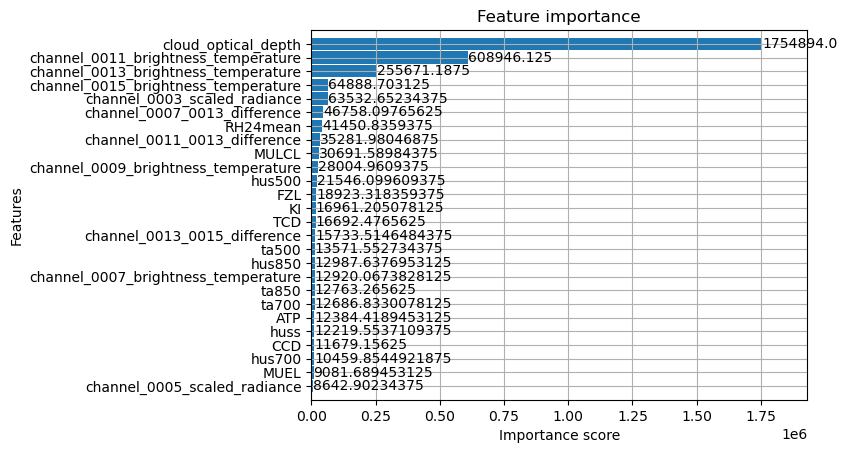

In [8]:
_ = xgb.plot_importance(model, height=0.9, importance_type="gain")

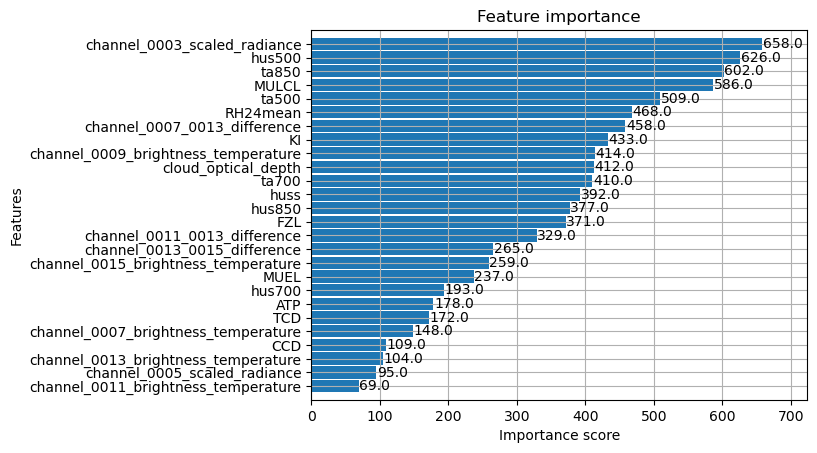

In [9]:
_ = xgb.plot_importance(model, height=0.9, importance_type="weight")

# SHAP Results

In [10]:
explainer = shap.Explainer(model)

idx = np.random.choice(len(X_test), size=20000, replace=False)
X_sample = X_test.iloc[idx]

shap_values = explainer(X_sample)

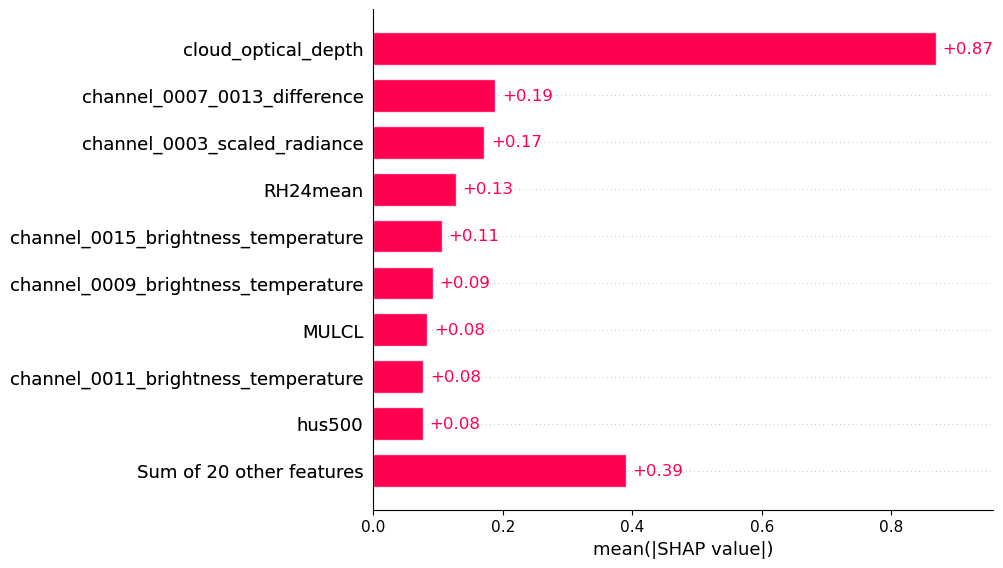

In [11]:
shap.plots.bar(shap_values)

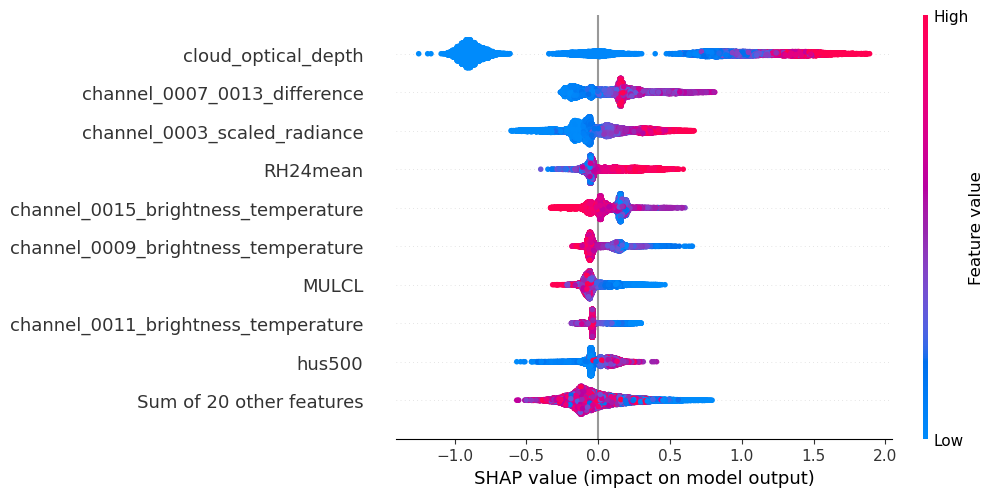

In [12]:
shap.plots.beeswarm(shap_values)